# RetailGenius — Exploratory Data Analysis

Quick look at the E-Commerce churn dataset. This notebook is *exploratory* — the production pipeline is in `src/churn/`.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from churn import config

sns.set_theme(style='whitegrid')
df = pd.read_excel(config.RAW_DATA_FILE, sheet_name=config.RAW_SHEET_NAME)
print(df.shape)
df.head()

(5630, 20)


,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


## 1. Schema and missing values

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   object 
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   object 
 7   Gender                       5630 non-null   object 
 8   HourSpendOnApp               5375 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   object 
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   object 
 13  NumberOfAddress   

In [3]:
missing = df.isna().sum()
missing[missing > 0].sort_values(ascending=False)

DaySinceLastOrder              307
OrderAmountHikeFromlastYear    265
Tenure                         264
OrderCount                     258
CouponUsed                     256
HourSpendOnApp                 255
WarehouseToHome                251
dtype: int64

Seven numeric columns have ~4-5% missing values each. We impute with the median inside the feature pipeline so the imputation is fit on the training fold only.

## 2. Target balance

In [4]:
ratio = df[config.TARGET].value_counts(normalize=True).rename({0: 'retained', 1: 'churned'})
ratio

Churn
retained    0.831616
churned     0.168384
Name: proportion, dtype: float64

~17% positive class — moderate imbalance, handled by `class_weight='balanced'` for LR/RF and `scale_pos_weight` for XGBoost.

## 3. Churn by key features

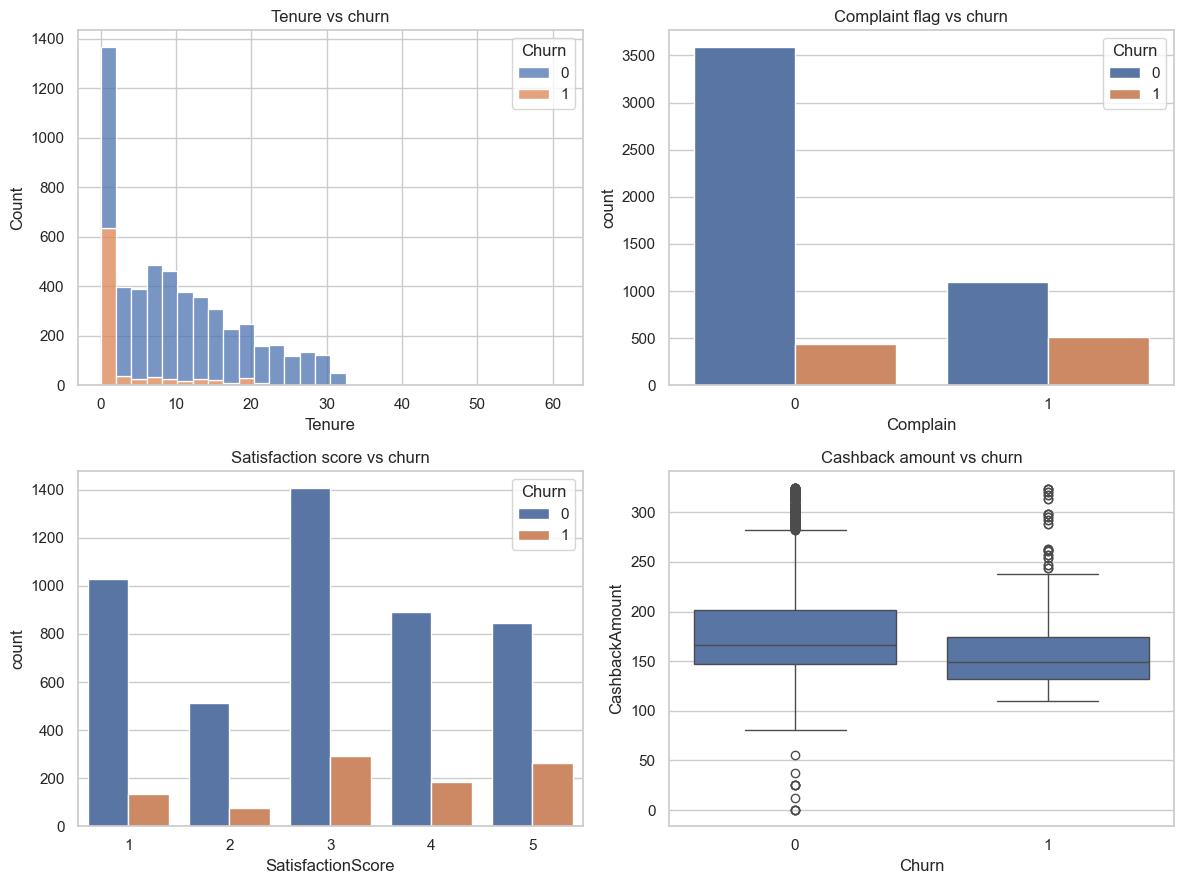

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

sns.histplot(data=df, x='Tenure', hue=config.TARGET, multiple='stack', bins=30, ax=axes[0, 0])
axes[0, 0].set_title('Tenure vs churn')

sns.countplot(data=df, x='Complain', hue=config.TARGET, ax=axes[0, 1])
axes[0, 1].set_title('Complaint flag vs churn')

sns.countplot(data=df, x='SatisfactionScore', hue=config.TARGET, ax=axes[1, 0])
axes[1, 0].set_title('Satisfaction score vs churn')

sns.boxplot(data=df, x=config.TARGET, y='CashbackAmount', ax=axes[1, 1])
axes[1, 1].set_title('Cashback amount vs churn')

plt.tight_layout()
plt.show()

Patterns worth flagging in the report:

- Low tenure customers churn much more often (acquisition cohort risk).
- Having raised a complaint correlates strongly with churning.
- Lower satisfaction scores correlate with higher churn rate.
- Cashback amount distributions are similar for the two classes, so it's likely a weaker feature.

## 4. Categorical feature breakdown

In [6]:
for col in config.CATEGORICAL:
    rates = df.groupby(col)[config.TARGET].agg(['mean', 'count']).sort_values('mean', ascending=False)
    print(f'\n{col}')
    print(rates)


PreferredLoginDevice
                          mean  count
PreferredLoginDevice                 
Phone                 0.224208   1231
Computer              0.198286   1634
Mobile Phone          0.125859   2765

PreferredPaymentMode
                          mean  count
PreferredPaymentMode                 
COD                   0.287671    365
E wallet              0.228013    614
CC                    0.216117    273
UPI                   0.173913    414
Cash on Delivery      0.154362    149
Debit Card            0.153846   2314
Credit Card           0.128581   1501

Gender
            mean  count
Gender                 
Male    0.177305   3384
Female  0.154942   2246

PreferedOrderCat
                        mean  count
PreferedOrderCat                   
Mobile Phone        0.275374   1271
Mobile              0.271941    809
Fashion             0.154964    826
Laptop & Accessory  0.102439   2050
Others              0.075758    264
Grocery             0.048780    410

MaritalStatus

## 5. Numeric correlations

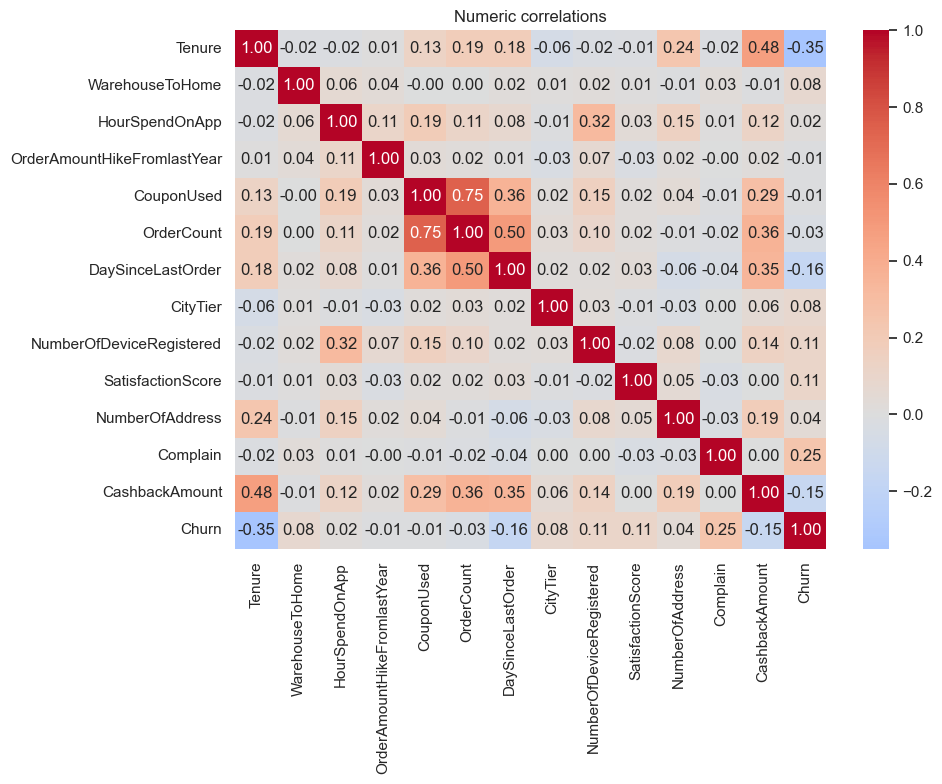

In [7]:
numeric_cols = config.NUMERIC_WITH_NAN + config.NUMERIC_NO_NAN + [config.TARGET]
corr = df[numeric_cols].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Numeric correlations')
plt.tight_layout()
plt.show()